## Import thư viện

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load dữ liệu

In [7]:
from google.colab import files
uploaded = files.upload()

Saving raw_data.csv to raw_data.csv


In [8]:
economy = pd.read_csv("raw_data.csv", index_col=0)
economy.head()

,Tiêu đề,Nội dung,Từ khóa,Chuyên mục,Nguồn
URL,,,,,
https://cafef.vn/tu-doanh-ctck-mua-rong-hon-700-ty-dong-phien-18-3-co-phieu-nao-la-tam-diem-188260318181834221.chn,Tự doanh CTCK mua ròng hơn 700 tỷ đồng phiên 1...,"Thị trường tiếp tục phục hồi trong phiên 18/3,...","tự doanh ctck,, cổ phiếu,, đầu tư,, chứng khoá...",Chứng khoán,CafeF
https://cafef.vn/vu-an-xay-ra-tai-acv-va-cac-don-vi-lien-quan-vao-dien-ban-chi-dao-tw-theo-doi-188260318180122104.chn,Vụ án xảy ra tại ACV và các đơn vị liên quan v...,"Ngày 18/3, Tổng Bí thư Tô Lâm chủ trì cuộc họp...","hàng không,, tham nhũng,, ACV",Chứng khoán,CafeF
https://cafef.vn/sap-bay-keu-goi-dau-tu-nguoi-dan-ong-o-da-nang-bi-chiem-doat-hon-25-ty-18826031817550736.chn,"'Sập bẫy' kêu gọi đầu tư, người đàn ông ở Đà N...",Cơ quan CSĐT Công an TP Đà Nẵng cho biết vừa b...,"đầu tư,, lừa đảo",Chứng khoán,CafeF
https://cafef.vn/bo-me-mr-pips-rut-ca-tram-ty-dong-mua-hang-tram-luong-vang-khi-con-trai-bi-bat-188260318175420192.chn,"Bố mẹ Mr Pips rút cả trăm tỷ đồng, mua hàng tr...",Cơ quan Cảnh sát điều tra Công an TP Hà Nội vừ...,"Mr Pips,, đầu tư,, lừa đảo,, tiền ảo,, vàng",Chứng khoán,CafeF
https://cafef.vn/hai-cuu-cong-an-nhan-thu-lao-2-ty-dong-lap-to-tu-van-giup-mr-pips-lua-dao-188260318175318445.chn,"Hai cựu công an nhận thù lao 2 tỷ đồng, lập 't...",Cơ quan CSĐT Công an Hà Nội vừa hoàn tất kết l...,"lừa đảo,, Mr Pips",Chứng khoán,CafeF


In [9]:
economy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2721 entries, https://cafef.vn/tu-doanh-ctck-mua-rong-hon-700-ty-dong-phien-18-3-co-phieu-nao-la-tam-diem-188260318181834221.chn to https://vietstock.vn/2026/02/dien-bien-moi-tai-sieu-du-an-o-quy-nhon-do-lien-danh-geleximco-trien-khai-4222-1403632.htm
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tiêu đề     2721 non-null   object
 1   Nội dung    2721 non-null   object
 2   Từ khóa     2663 non-null   object
 3   Chuyên mục  2721 non-null   object
 4   Nguồn       2721 non-null   object
dtypes: object(5)
memory usage: 127.5+ KB


## Phân tích Dữ liệu (Exploratory Data Analysis)

/tmp/ipykernel_1293/3032064252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


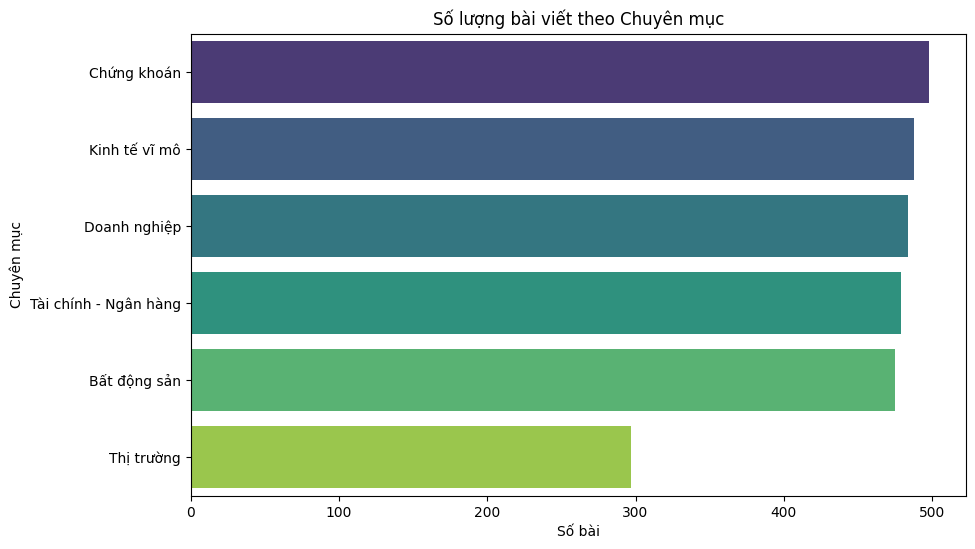


Thống kê Độ dài bài viết:
count    2721.000000
mean      778.224182
std       417.401050
min        25.000000
25%       492.000000
50%       698.000000
75%       971.000000
max      4650.000000
Name: Số lượng từ, dtype: float64


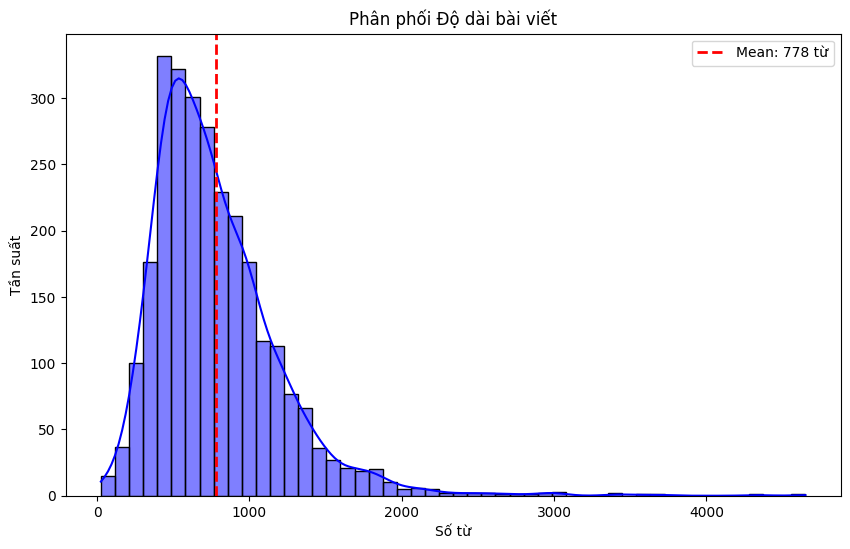


Số bài báo bị khuyết Từ khóa: 58 (2.13%)


In [58]:
# Thống kê theo Chuyên mục
cat_counts = economy['Chuyên mục'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('Số lượng bài viết theo Chuyên mục')
plt.xlabel('Số bài')
plt.ylabel('Chuyên mục')
plt.show()

# Độ dài bài viết (Số lượng từ)
economy['Số lượng từ'] = economy['Nội dung'].astype(str).apply(lambda x: len(x.split()))

print("\nThống kê Độ dài bài viết:")
print(economy['Số lượng từ'].describe())

plt.figure(figsize=(10,6))
sns.histplot(economy['Số lượng từ'], bins=50, kde=True, color='blue')
plt.axvline(economy['Số lượng từ'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {economy['Số lượng từ'].mean():.0f} từ")
plt.title('Phân phối Độ dài bài viết')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

# Tỷ lệ khuyết Từ khóa
missing_kw = economy['Từ khóa'].isna().sum()
print(f"\nSố bài báo bị khuyết Từ khóa: {missing_kw} ({missing_kw/len(economy)*100:.2f}%)")

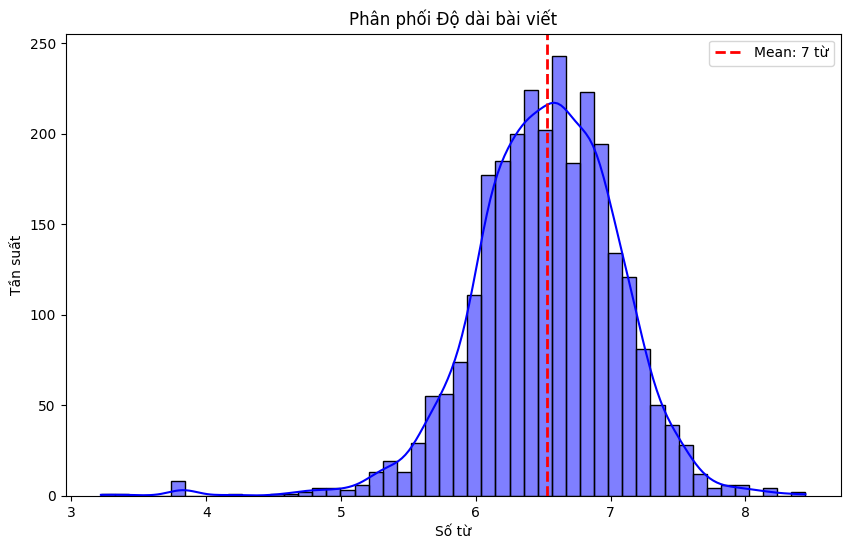

In [59]:
plt.figure(figsize=(10,6))
sns.histplot(np.log(economy['Số lượng từ']), bins=50, kde=True, color='blue')
plt.axvline(np.log(economy['Số lượng từ']).mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {np.log(economy['Số lượng từ']).mean():.0f} từ")
plt.title('Phân phối Độ dài bài viết')
plt.xlabel('Số từ')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

/tmp/ipykernel_1293/1822781667.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='magma')


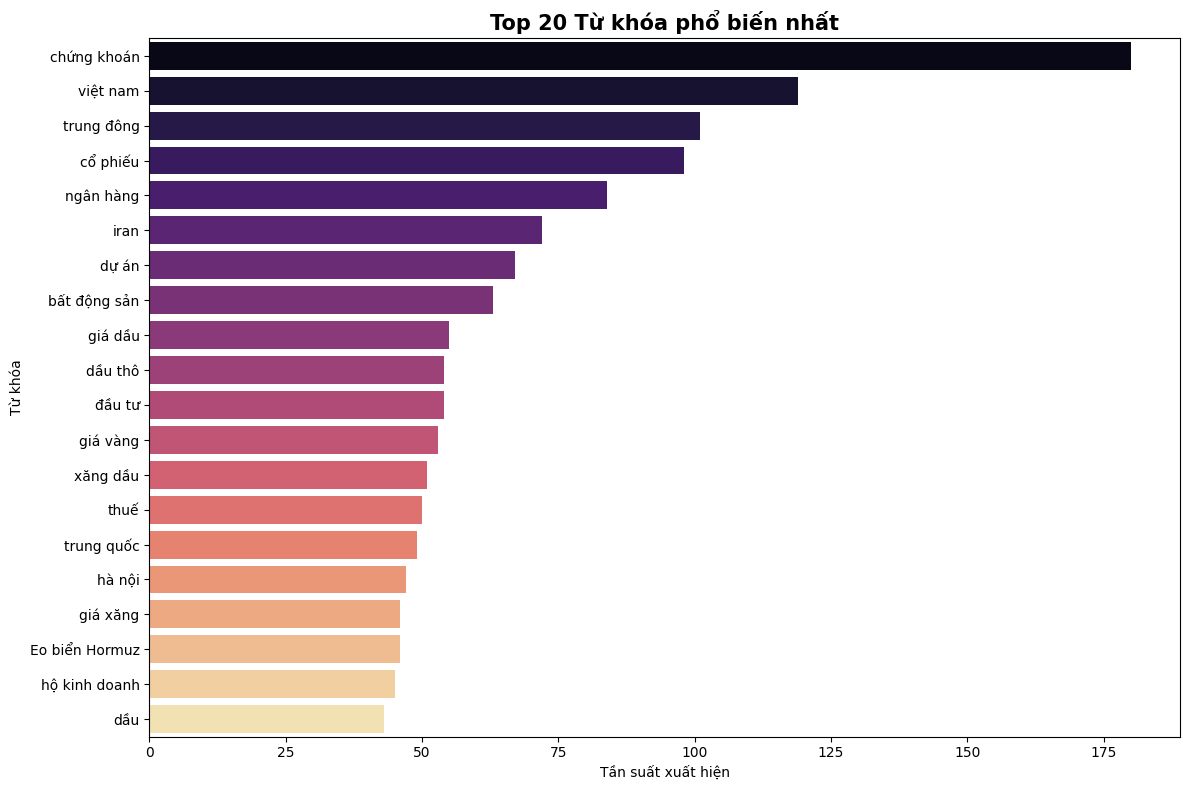

In [60]:
# 4.4 Khai phá Top 20 Từ khóa xuất hiện nhiều nhất
# Xử lý chuỗi từ khóa, tách bằng dấu phẩy và làm sạch khoảng trắng
keywords = economy['Từ khóa'].dropna().astype(str).str.split(',').explode().str.strip()
keywords = keywords[keywords != ""] # Bỏ các tag rỗng
top_keywords = keywords.value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='magma')
plt.title('Top 20 Từ khóa phổ biến nhất', fontsize=15, fontweight='bold')
plt.xlabel('Tần suất xuất hiện')
plt.ylabel('Từ khóa')
plt.tight_layout()
plt.show()

## Tạo tập copy & Ghép cột "Tiêu đề" và "Nội Dung"

In [10]:
economy_copy = economy.copy()
economy_copy["text"] = economy_copy["Tiêu đề"] + " " + economy_copy["Nội dung"]

## Clean text

In [11]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)   # remove url
    text = re.sub(r"<.*?>", "", text)     # remove html
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)  # remove punctuation

    return text

economy_copy["clean_text"] = economy_copy["text"].apply(clean_text)

## Lọc các bài viết không liên quan

#### Phương pháp TF-IDF + Cosine similarity

In [12]:
seed_texts_vi = [

"""
thị trường chứng khoán việt nam vn-index tăng giảm
cổ phiếu doanh nghiệp niêm yết giao dịch trên sàn hose hnx upcom
nhà đầu tư mua bán cổ phiếu theo diễn biến thị trường
""",

"""
chỉ số vn-index phản ánh biến động thị trường chứng khoán
các cổ phiếu vốn hóa lớn bluechip ảnh hưởng đến xu hướng thị trường
nhà đầu tư theo dõi thanh khoản và khối lượng giao dịch
""",

"""
doanh nghiệp niêm yết công bố kết quả kinh doanh
lợi nhuận doanh thu ảnh hưởng giá cổ phiếu trên thị trường chứng khoán
nhà đầu tư phân tích báo cáo tài chính trước khi đầu tư
""",

"""
sàn giao dịch chứng khoán hose hnx và upcom
niêm yết cổ phiếu của các doanh nghiệp việt nam
nhà đầu tư cá nhân và tổ chức tham gia thị trường
""",

"""
dòng tiền đầu tư vào thị trường chứng khoán
nhà đầu tư mua cổ phiếu khi vn-index tăng trưởng
thị trường tài chính phản ánh kỳ vọng kinh tế
""",

"""
khối ngoại mua bán ròng cổ phiếu trên sàn chứng khoán
thanh khoản thị trường tăng khi nhà đầu tư giao dịch mạnh
chỉ số vn-index dao động theo cung cầu cổ phiếu
""",

"""
các công ty chứng khoán đưa ra khuyến nghị đầu tư
nhà đầu tư theo dõi xu hướng vn-index và cổ phiếu bluechip
thị trường chứng khoán phản ánh kỳ vọng kinh tế
""",

"""
giá cổ phiếu của các doanh nghiệp niêm yết biến động
theo thông tin kết quả kinh doanh và triển vọng ngành
nhà đầu tư phân tích thị trường trước khi ra quyết định
"""
]

In [13]:
seed_texts_en = [

"""
Vietnam stock market VN-Index increased as investors bought shares
listed companies on HOSE HNX and UPCOM attracted strong trading volume
market liquidity improved as investors returned to equities
""",

"""
The VN-Index reflects the performance of the Vietnam stock market
large-cap blue chip stocks influence the overall market trend
investors monitor trading volume and market liquidity
""",

"""
Listed companies on the Ho Chi Minh Stock Exchange reported strong earnings
corporate profits and financial results affect stock prices
investors analyze financial statements before making investment decisions
""",

"""
Foreign investors bought and sold Vietnamese stocks
trading activity increased on HOSE and HNX exchanges
market sentiment improved as investors expected economic growth
""",

"""
Vietnam equities gained as the VN-Index moved higher
investors increased exposure to blue chip stocks
market liquidity and trading volume rose significantly
""",

"""
Stock prices of listed companies fluctuate based on earnings reports
corporate announcements and economic outlook affect investor sentiment
traders monitor market movements and investment opportunities
""",

"""
Vietnamese stock exchanges including HOSE HNX and UPCOM
provide platforms for trading shares of listed companies
domestic and foreign investors participate in the equity market
""",

"""
Securities firms issued investment recommendations
analysts expect the Vietnam stock market to grow
investors track the VN-Index and sector performance
"""
]

In [14]:
seed_texts = seed_texts_vi + seed_texts_en

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

all_texts = economy_copy["clean_text"].tolist() + seed_texts
tfidf = vectorizer.fit_transform(all_texts)

In [16]:
article_vectors = tfidf[:-len(seed_texts)]
seed_vectors = tfidf[-len(seed_texts):]

centroid = np.asarray(seed_vectors.mean(axis=0))

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(article_vectors, centroid)

In [18]:
economy_copy["topic_score"] = scores

tf_idf_rate = economy_copy["topic_score"].mean()

#### Phương pháp word filter

In [19]:
economic_keywords = [
    "kinh tế","lạm phát","tăng trưởng", "giá cả","thị trường","đầu tư",
    "giá", "gdp","inflation","interest rate",
    "monetary","fiscal"
]

def is_economic(text):
    text = text.lower()

    for kw in economic_keywords:
        if kw in text:
            return True

    return False

#### So sánh

In [20]:
print((economy_copy["topic_score"] > 0.10).sum())
print(economy_copy["clean_text"].apply(is_economic).sum())

763
2548


In [21]:
economy_copy = economy_copy[economy_copy["clean_text"].apply(is_economic)]

#### Reset index

In [22]:
economy_copy = economy_copy.reset_index()
economy_copy["clean_text"].index

RangeIndex(start=0, stop=2548, step=1)

In [23]:
economy_copy["clean_text"].head()

,clean_text
0,Tự doanh CTCK mua ròng hơn 700 tỷ đồng phiên 1...
1,Vụ án xảy ra tại ACV và các đơn vị liên quan v...
2,Sập bẫy kêu gọi đầu tư người đàn ông ở Đà N...
3,Bố mẹ Mr Pips rút cả trăm tỷ đồng mua hàng tr...
4,Hai cựu công an nhận thù lao 2 tỷ đồng lập t...


## Detect ngôn ngữ

In [26]:
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

economy_copy["lang"] = economy_copy["clean_text"].apply(detect_lang)

In [27]:
economy_copy["lang"].value_counts()

,count
lang,
vi,2548


In [28]:
economy_copy = economy_copy[economy_copy["lang"].isin(["vi","en"])]
economy_copy["lang"].value_counts()

,count
lang,
vi,2548


## Chuẩn hóa text

In [29]:
economy_copy["clean_text"] = economy_copy["clean_text"].str.lower()

## Tính toán sentiment

#### Dùng phoBERT

In [37]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "wonrax/phobert-base-vietnamese-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

texts = economy_copy["clean_text"].tolist()

batch_size = 32
scores = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    inputs = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

    scores.extend((preds).cpu().numpy())

economy_copy["sentiment_score"] = scores

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: wonrax/phobert-base-vietnamese-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
economy_copy["sentiment_score"].value_counts()

,count
sentiment_score,
0,905
1,870
2,773


In [40]:
mapping = {
    0.0 : -1,
    1.0 : 0,
    2.0 : 1
}

economy_copy["sentiment_score_mapping"] = economy_copy["sentiment_score"].map(mapping)
economy_copy["sentiment_score_mapping"]

,sentiment_score_mapping
0,1
1,-1
2,-1
3,-1
4,-1
...,...
2543,1
2544,1
2545,-1
2546,-1


#### Dùng "đếm từ"

In [61]:
positive_words = set([
    "tăng","tốt","tích cực","lợi nhuận" "phát triển",
    "growth","increase","positive","profit","improve"
])

negative_words = set([
    "giảm","xấu","tiêu cực","lỗ","khủng hoảng",
    "decrease","negative","loss","crisis","decline"
])

In [62]:
def lexicon_sentiment(text):
    tokens = text.split()

    pos_count = sum(1 for t in tokens if t in positive_words)
    neg_count = sum(1 for t in tokens if t in negative_words)

    if pos_count + neg_count == 0:
        return 0  # neutral

    score = (pos_count-neg_count) / (pos_count+neg_count)
    return score

In [63]:
economy_copy["lexicon_score"] = economy_copy["clean_text"].apply(lexicon_sentiment)

In [64]:
def map_label(score):
    if score > 0.1:
        return 1
    elif score < -0.1:
        return -1
    else:
        return 0

economy_copy["lexicon_label"] = economy_copy["lexicon_score"].apply(map_label)

In [65]:
economy_copy["compare"] = (
    economy_copy["sentiment_score_mapping"] == economy_copy["lexicon_label"]
)

In [69]:
economy_copy["compare"].value_counts()

,count
compare,
False,1691
True,857


Text(0, 0.5, 'Frequency')

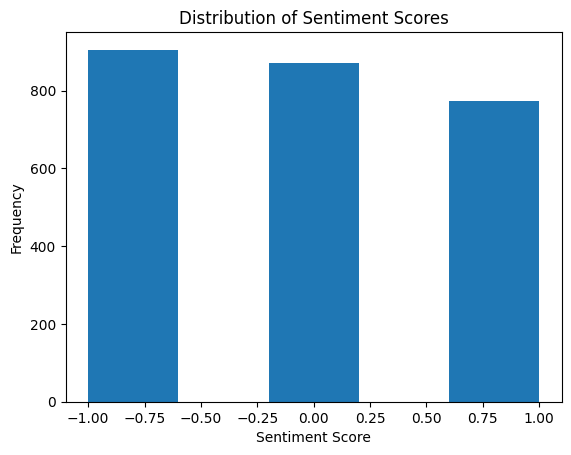

In [46]:
economy_copy["sentiment_score_mapping"].plot.hist(bins=5)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

## Sentiment trung bình theo ngày

In [41]:
def extract_date(text, url):
    from_cafef = url[0:17]=="https://cafef.vn"
    # 1. lấy từ nội dung (Vietstock)
    match = re.search(r'(\d{2}:\d{2}\s\d{2}/\d{2}/\d{4})', str(text))
    if ~from_cafef and match:
        return match.group(1)

    # 2. fallback: lấy từ URL (CafeF)
    match_url = re.search(r'(\d{6})\d{9}\.chn', str(url))
    if from_cafef and match_url:
        d = match_url.group(1)
        return f"00:00 {d[4:6]}/{d[2:4]}/20{d[0:2]}"

    return None

economy_copy['Ngày đăng'] = economy_copy.apply(lambda x: extract_date(x['Nội dung'], x['URL']), axis=1)

/tmp/ipykernel_1293/2469047745.py:5: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  if ~from_cafef and match:


In [42]:
economy_copy["Ngày đăng"] = pd.to_datetime(
    economy_copy["Ngày đăng"],
    format="%H:%M %d/%m/%Y"
    )

daily_sentiment = economy_copy.groupby(
    economy_copy["Ngày đăng"].dt.date
)["sentiment_score_mapping"].mean().reset_index(name="avg_sentiment")

In [43]:
daily_sentiment

,Ngày đăng,avg_sentiment
0,2026-02-05,0.333333
1,2026-02-06,0.000000
2,2026-02-07,1.000000
3,2026-02-08,0.333333
4,2026-02-09,-0.444444
5,2026-02-10,0.714286
6,2026-02-11,-0.250000
7,2026-02-12,-0.166667
8,2026-02-13,-0.200000
9,2026-02-14,0.250000


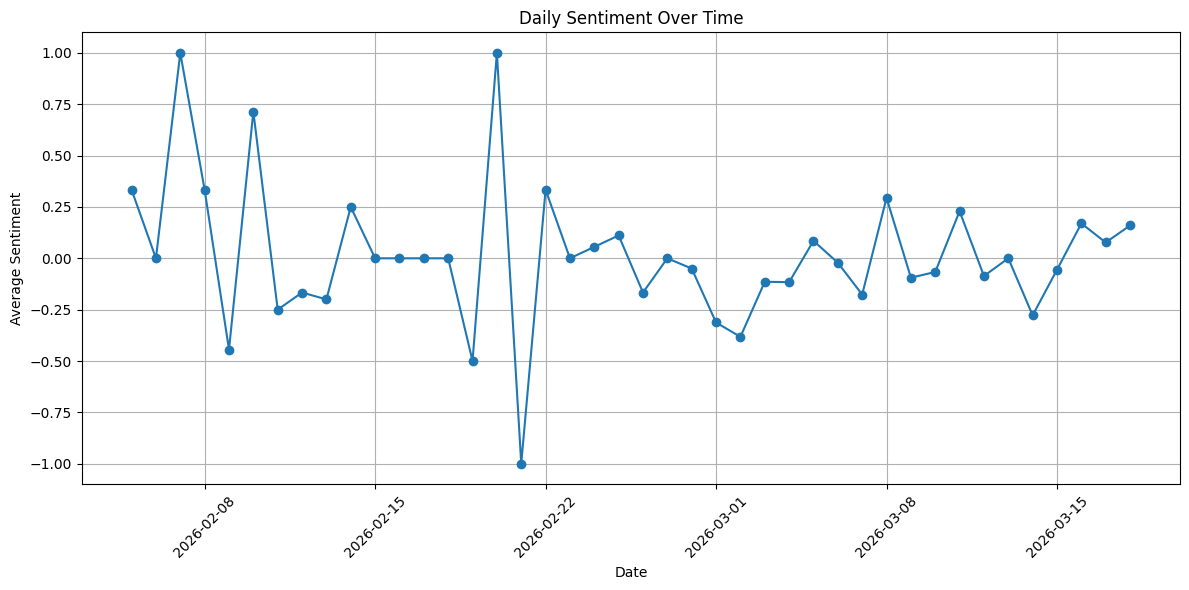

In [71]:
plt.figure(figsize=(12,6))
plt.plot(daily_sentiment["Ngày đăng"], daily_sentiment["avg_sentiment"], marker='o')

plt.title("Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## Word tokenize

In [50]:
from underthesea import word_tokenize

economy_copy["token_text"] = economy_copy.apply(
    lambda x: word_tokenize(x["clean_text"], format="text"),
    axis=1
)

## Loại bỏ stopwords

In [51]:
from nltk.corpus import stopwords

stop_words = {
    "và","là","của","có","cho","trong","một","những","được","với","các",
    "đã","này","đó","khi","đến","từ","ra","rằng","thì","vì","mà","nên",
    "như","để","sau","trước","vẫn","còn","cũng","lại","rất","hơn","ít",
    "nhiều","từng","tại","theo","qua","về","đi","lên","xuống","vào",
    "giữa","ngoài","trên","dưới","bên","cùng","cùng_với"
}
domain_stopwords = {
    "việt_nam","việt","nam",
    "theo","cho_biết","cho_rằng",
    "thông_tin","được_biết",
    "cơ_quan","bộ","ngành",
    "tỷ","triệu","tỷ_đồng",
    "năm","tháng","ngày"
}
stop_words = stop_words.union(domain_stopwords)

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

economy_copy["token_text"] = economy_copy.apply(
    lambda x: remove_stopwords(x["token_text"]),
    axis=1
)

## Vẽ word cloud

In [52]:
all_text = " ".join(economy_copy["token_text"])

In [54]:
from google.colab import files
uploaded = files.upload()

Saving arial.ttf to arial.ttf


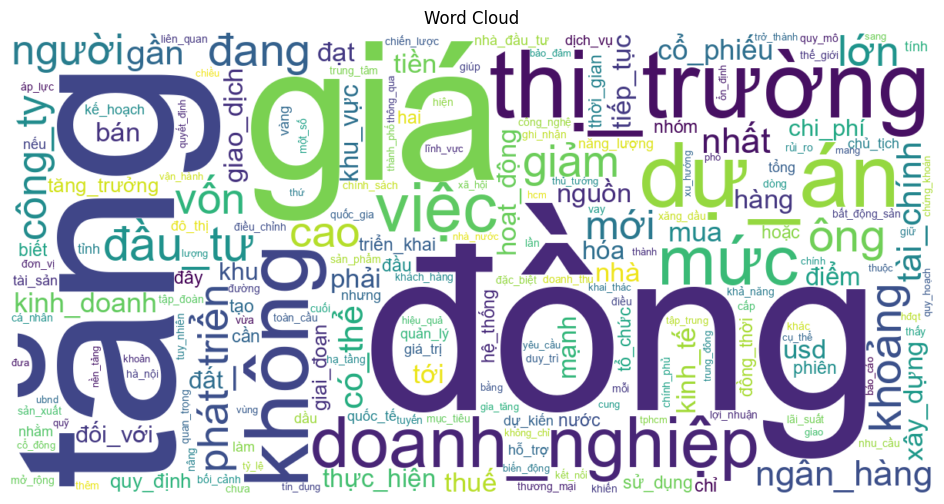

In [55]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False,  # tránh ghép từ sai
    font_path="arial.ttf"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [56]:
positive_text = " ".join(economy_copy[economy_copy["sentiment_score_mapping"] > 0]["token_text"])

negative_text = " ".join(economy_copy[economy_copy["sentiment_score_mapping"] < 0]["token_text"])

neutral_text = " ".join(economy_copy[economy_copy["sentiment_score_mapping"] == 0]["token_text"])

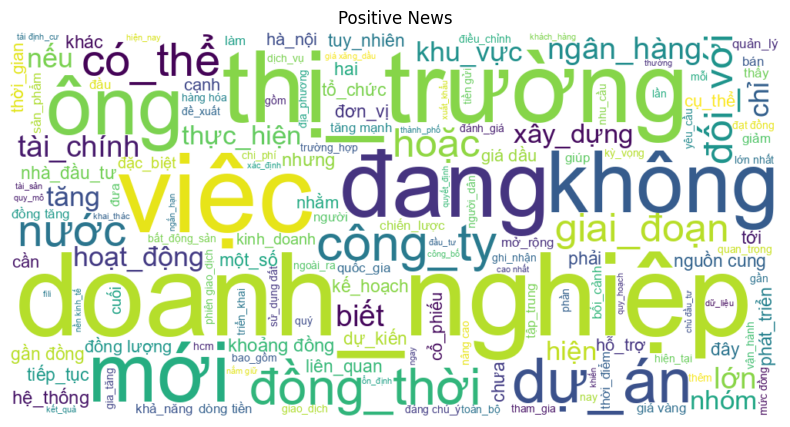

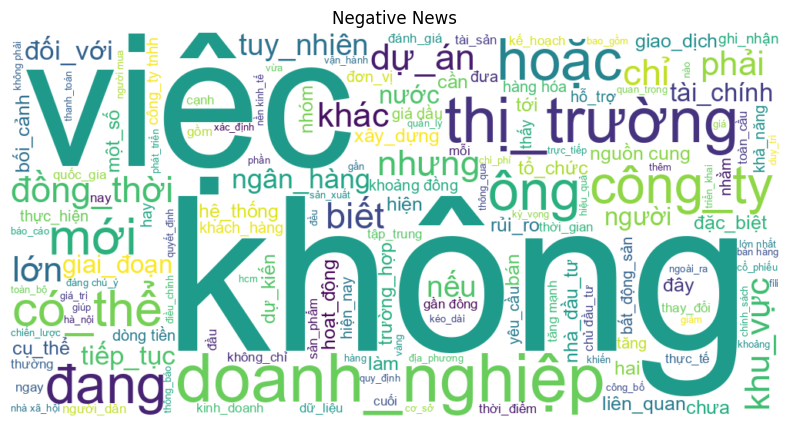

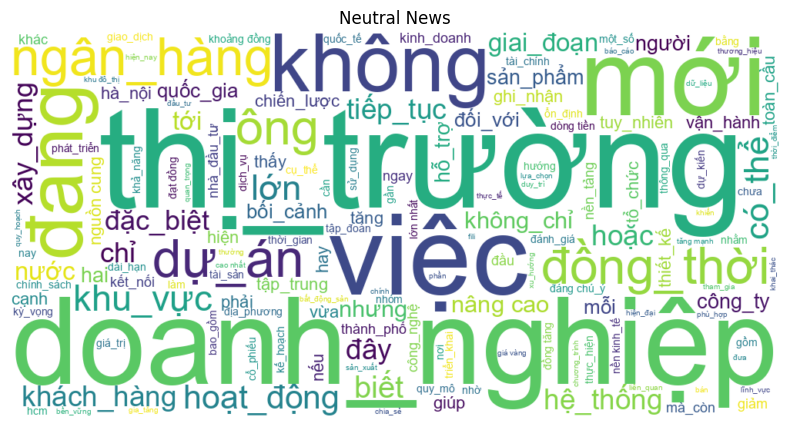

In [57]:
def plot_wc(text, title):
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        font_path="arial.ttf",
        max_words=150
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wc(positive_text, "Positive News")
plot_wc(negative_text, "Negative News")
plot_wc(neutral_text, "Neutral News")